# Generate Plots of Absolute Geostrophic Velocity in transects of the Beaufort Gyre

### Configure the notebook and load necessary packages

In [1]:
#Jupyter Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
#Load necessary python packages
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np

from ipywidgets import widgets
from IPython.display import display

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.ctd.operations as dsops
import datatools.plots.maps as mapper
import datatools.plots.section as plotter
import ocean_tools as fod
from datatools.DOT.DataServer import DataServer

### Extract the CTD Transects from the full dataset
* Read in the data
* Extract each transect
* Plot the transects on a map

In [3]:
#Read raw CTD data
ds = io.readers.readLSSL("/Users/ben/Desktop/3D-TEA-BAG/data/BG_LSSL_CTD_2003-2025.nc")

#Slice the data to extract each transect
#Eastern N-S transect (IVO 140˚W)
e_ns_transect = dsops.var_slice(ds, 'lon', -140.5, -139.5)
#ADD OTHER THREE TRANSECTS

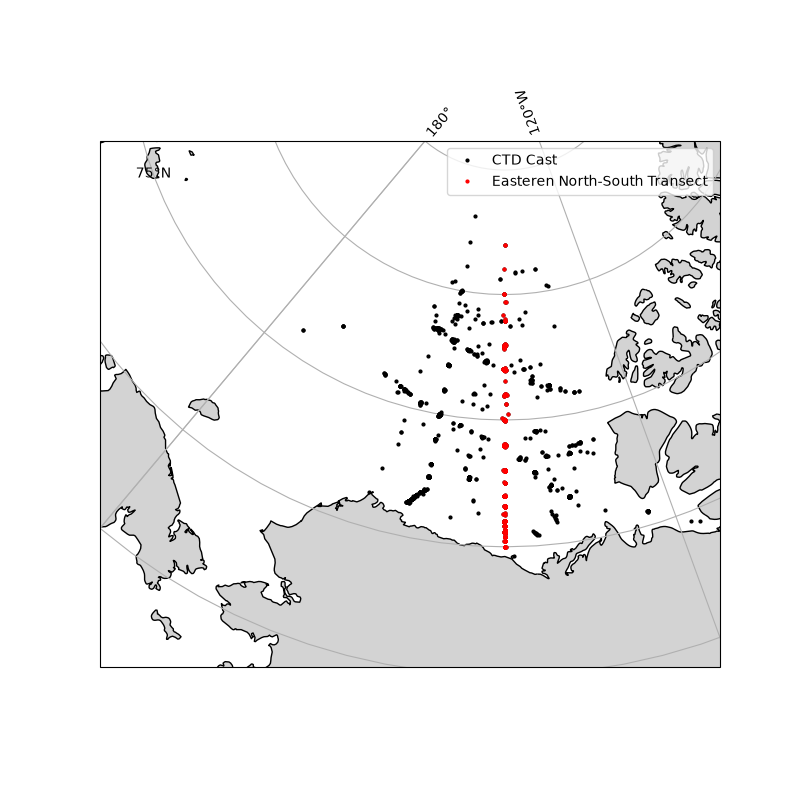

In [4]:
#Plot the transects

#Setup the basemap
transect_location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]

ax = mapper.setup_map(figure=transect_location_figure,
                 projection=projection,
                 extent=extent)

#Plot all casts
ax = mapper.plot_station_locations(ax = ax, ds = ds, label = 'CTD Cast')

#Plat the transects
ax = mapper.plot_station_locations(ax = ax, ds = e_ns_transect, color='r', label = 'Easteren North-South Transect')

#Finish the plot off
plt.title("Beaufort Gyre Exploration Project Shipboard CTD Cast Locations") #WHY DOESNT THIS WORK?
plt.legend()

plt.show()

### Preprocess the CTD Transects
* Split each transect dataset into an array of data arrays (one for each cruise year)
* Run the injest/cleaning function on each array of transects to remove nan data, calculate various parameters, ensure all variable naming is consistent, and add variable metadata to easier plotting later on
* Includes calculature thermal wind shear ($\frac{\partial U_g}{\partial z} = \frac{g}{\rho f_c}\frac{\partial \rho}{\partial y}$)

In [5]:
#Split data into a dataset per cruise 
e_ns_cruise_transects = dsops.split_by_coordinate(e_ns_transect, 'cruise')
#Clean each dataset
for key in e_ns_cruise_transects:
    #Clean and injest the transect data (add many new and useful variables)
    e_ns_cruise_transects[key] = dsops.injest_CTD_transect(e_ns_cruise_transects[key], datum=(70,-140))

### Calculate Absolute Geostrophic Velocity
$\vec{V_g} = \int_{z_0}^{z} \frac{\partial \vec{V_g}}{\partial z} \,dz + \vec{V}_{g, z_0}$
1. Calculate based on a level of no motion of 1000m
2. Calculate based on satelite derived surface geostrophic current


In [6]:
#Load in Satellite Data
sat_data = DataServer("/Users/ben/Desktop/3D-TEA-BAG/data/CPOM_DOT.nc", "/Users/ben/Desktop/3D-TEA-BAG/data/Full_DOT_data_Arco_2025_09.nc")

for key in e_ns_cruise_transects:
    transect = e_ns_cruise_transects[key]

    #1000m level of no motion
    abs_geo_vel = dsops.integrate_from_level_of_no_motion(transect, 1000)
    transect['asv_lom_1000'] = abs_geo_vel


    #Satellite Derived Geostrophic Current
    abs_geo_vel = dsops.integrate_from_surface_current(transect, sat_data, 'new', 'ns')
    transect['asv_surf_current'] = abs_geo_vel

    e_ns_cruise_transects[key] = transect

/Users/ben/.pyenv/versions/3tb-env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/Users/ben/.pyenv/versions/3tb-env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1329: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/ben/.pyenv/versions/3tb-env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1330: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/ben/.pyenv/versions/3tb-env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1339: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \
/Users/ben/Desktop/3D-TEA-BAG/datatools/DOT/DataServer.py:201: UserWarning: 2025-10-15T20:00:36.999999992 is after the end of the covered timeperiod
  warnings.warn(f"{working_time} is after the end of the covere

#### From Level of No Motion at 1000m

IntSlider(value=2016, continuous_update=False, description='Year:', max=2025, min=2003)

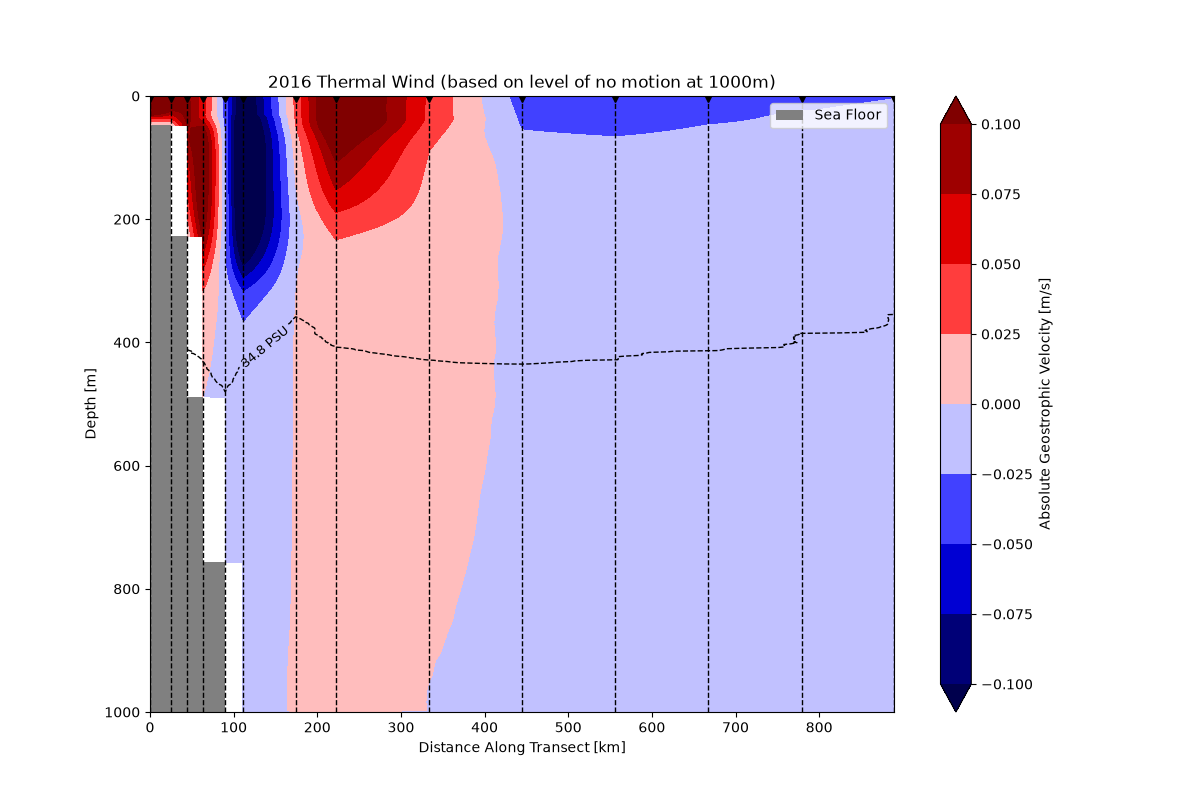

In [7]:
default_year = 2016

fig = plt.figure(figsize=(12,8))

year_slider = widgets.IntSlider(
    value=default_year,
    min=2003,
    max=2025,
    step=1,
    description='Year:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

def plot_lom_transect(change, fig):
    fig.clf()
    ax = fig.add_subplot(1,1,1) 

    year = change['new']
    transect = e_ns_cruise_transects[year]

    fig, ax = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'asv_lom_1000',
        fig = fig,
        ax = ax,
        cmap = colormaps['seismic'],
        title = f'{year} Thermal Wind (based on level of no motion at 1000m)',
        levels = 0.1,
        bounds = {'top': 0, 'bottom': 1000, 'left': 0, 'right': None}
        )


year_slider.observe(lambda b: plot_lom_transect(b, fig), names='value')

display(year_slider)

#Run callback on startup
plot_lom_transect({'new': default_year}, fig,)

plt.show()


#### From Satelite Derived Surface Geostrophic Current

IntSlider(value=2016, continuous_update=False, description='Year:', max=2025, min=2003)

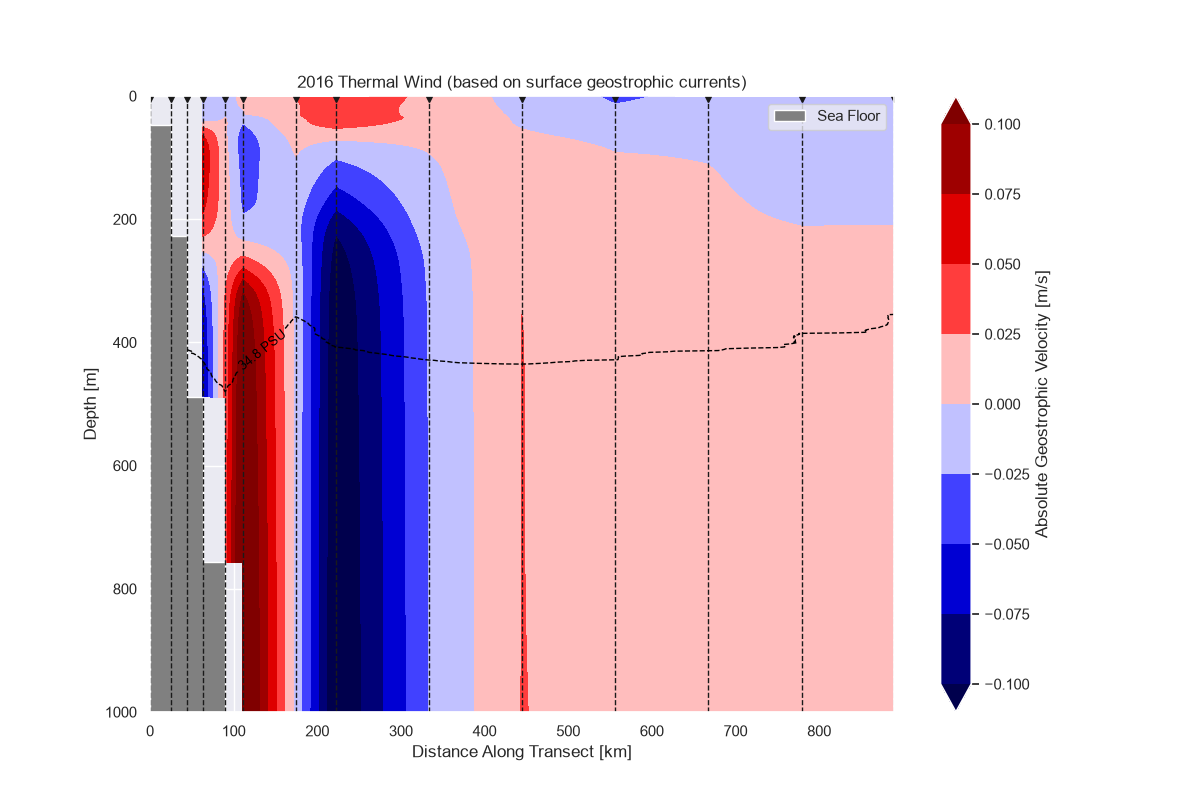

In [8]:
default_year = 2016

sns.set_theme()

fig = plt.figure(figsize=(12,8))

year_slider = widgets.IntSlider(
    value=default_year,
    min=2003,
    max=2025,
    step=1,
    description='Year:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

def plot_lom_transect(change, fig):
    fig.clf()
    ax = fig.add_subplot(1,1,1) 

    year = change['new']
    transect = e_ns_cruise_transects[year]

    fig, ax = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'asv_surf_current',
        fig = fig,
        ax = ax,
        cmap = colormaps['seismic'],
        title = f'{year} Thermal Wind (based on surface geostrophic currents)',
        levels = 0.1,
        bounds = {'top': 0, 'bottom': 1000, 'left': 0, 'right': None}
        )


year_slider.observe(lambda b: plot_lom_transect(b, fig), names='value')

display(year_slider)

#Run callback on startup
plot_lom_transect({'new': default_year}, fig,)

plt.show()

#### Combined Figure

IntSlider(value=2016, continuous_update=False, description='Year:', max=2025, min=2003)

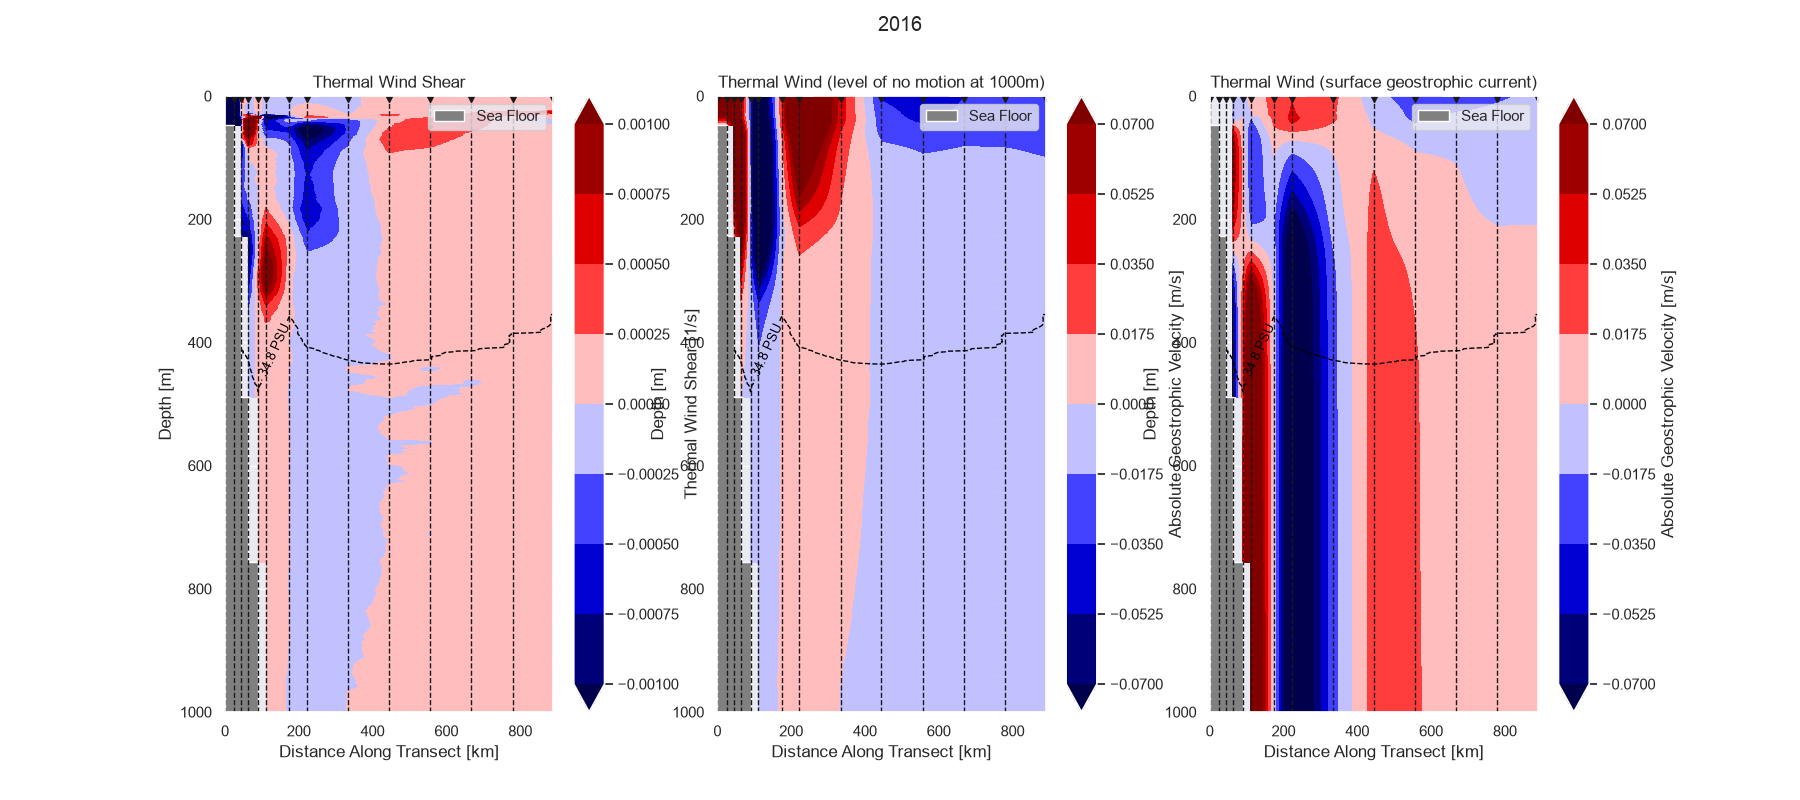

In [9]:
default_year = 2016

fig = plt.figure(figsize=(18,8))

year_slider = widgets.IntSlider(
    value=default_year,
    min=2003,
    max=2025,
    step=1,
    description='Year:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

def plot_lom_transect(change, fig):
    fig.clf()
    axs = fig.subplots(1,3) 

    year = change['new']
    transect = e_ns_cruise_transects[year]

    ax = axs[0]
    fig, ax = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'twind',
        fig = fig,
        ax = ax,
        cmap = colormaps['seismic'],
        title = f'Thermal Wind Shear',
        levels = 0.001,
        bounds = {'top': 0, 'bottom': 1000, 'left': 0, 'right': None}
        )

    ax = axs[1]
    fig, ax = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'asv_lom_1000',
        fig = fig,
        ax = ax,
        cmap = colormaps['seismic'],
        title = f'Thermal Wind (level of no motion at 1000m)',
        levels = 0.07,
        bounds = {'top': 0, 'bottom': 1000, 'left': 0, 'right': None}
        )

    ax = axs[2]
    fig, ax = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'asv_surf_current',
        fig = fig,
        ax = ax,
        cmap = colormaps['seismic'],
        title = f'Thermal Wind (surface geostrophic current)',
        levels = 0.07,
        bounds = {'top': 0, 'bottom': 1000, 'left': 0, 'right': None}
        )

    fig.suptitle(str(year))

year_slider.observe(lambda b: plot_lom_transect(b, fig), names='value')

display(year_slider)

#Run callback on startup
plot_lom_transect({'new': default_year}, fig)

plt.show()

### Generate large figure with transects from each year for easy comparison

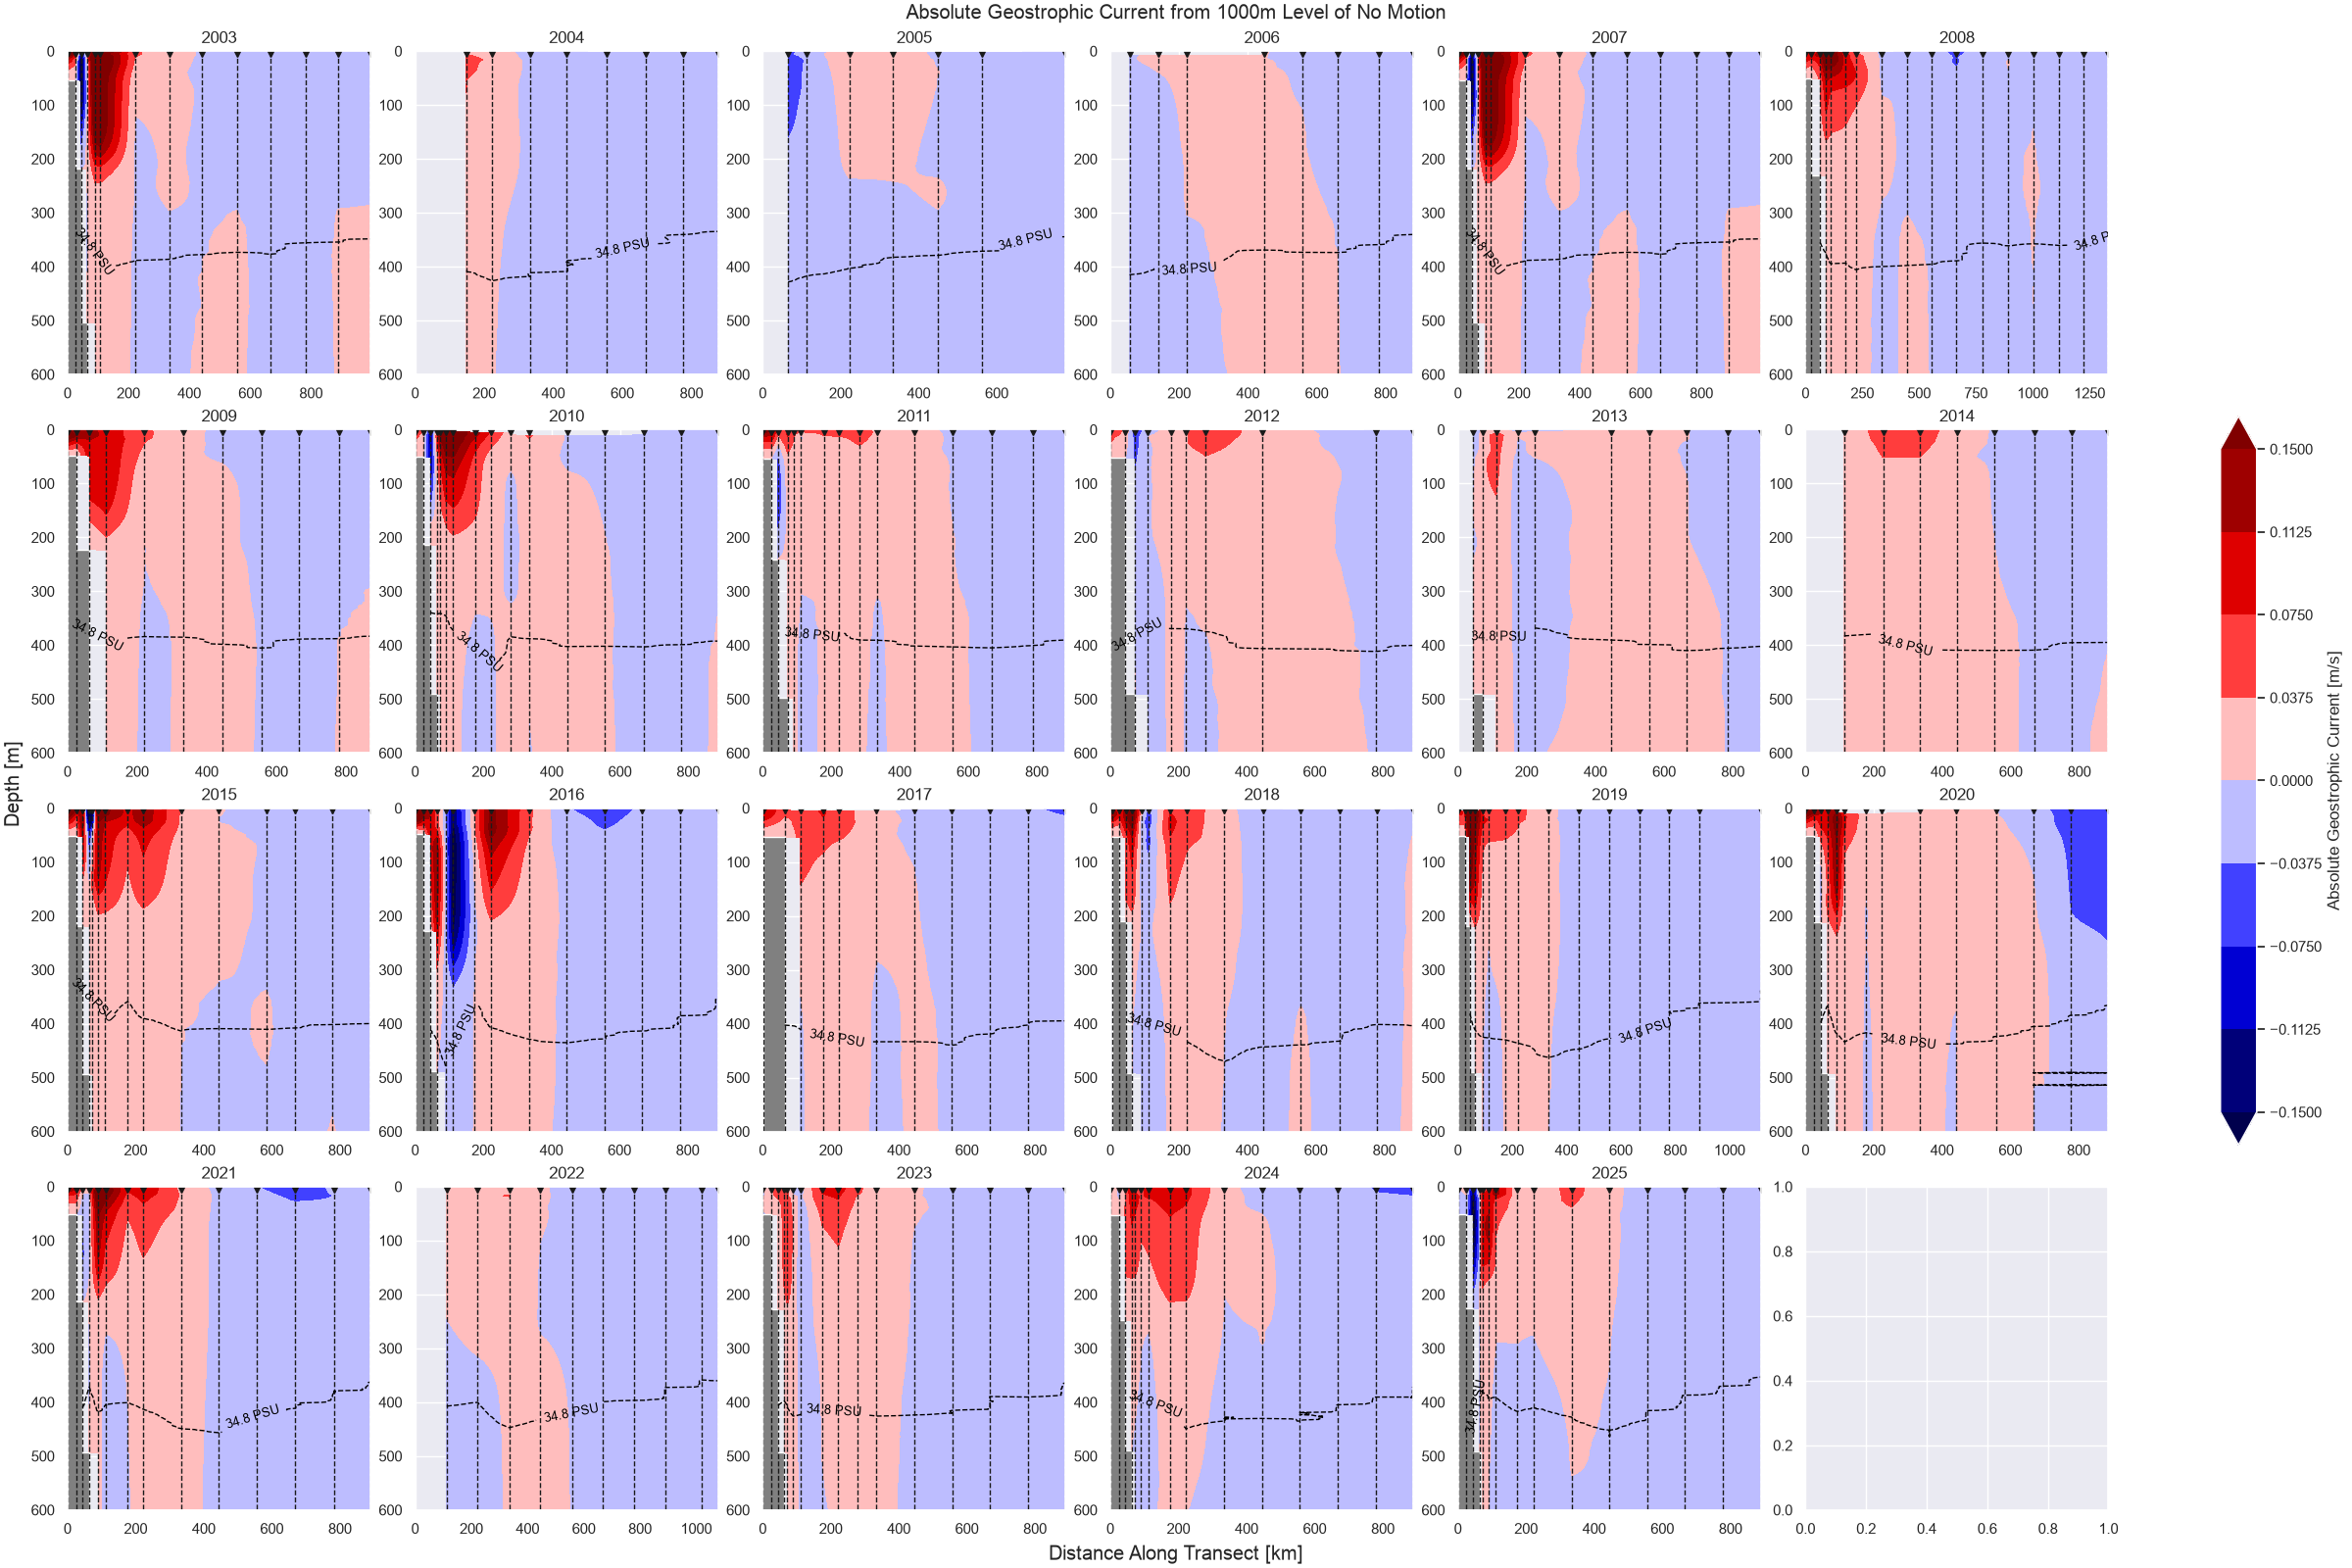

In [10]:
sat_derived_figure, axs = plt.subplots(4,6, figsize = (24, 16), layout="constrained")

sns.set_theme()

for i, key in enumerate(e_ns_cruise_transects):
    year = key
    transect = e_ns_cruise_transects[year]

    index = np.unravel_index(i, (4,6))

    sat_derived_figure, axs[index], cbar_obj = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'asv_lom_1000',
        fig = sat_derived_figure,
        ax = axs[index],
        cmap = colormaps['seismic'],
        title = str(year),
        levels = 0.15,
        colorbar = False,
        bounds = {'top': 0, 'bottom': 600, 'left': 0, 'right': None},
        xlabel=False,
        ylabel=False,
        legend=False
    )

sat_derived_figure.suptitle("Absolute Geostrophic Current from 1000m Level of No Motion")
sat_derived_figure.supxlabel("Distance Along Transect [km]")
sat_derived_figure.supylabel("Depth [m]")
sat_derived_figure.colorbar(cbar_obj, ax = axs, label = "Absolute Geostrophic Current [m/s]", shrink = 0.5)
plt.show()

IntSlider(value=2016, continuous_update=False, description='Year:', max=2025, min=2003)

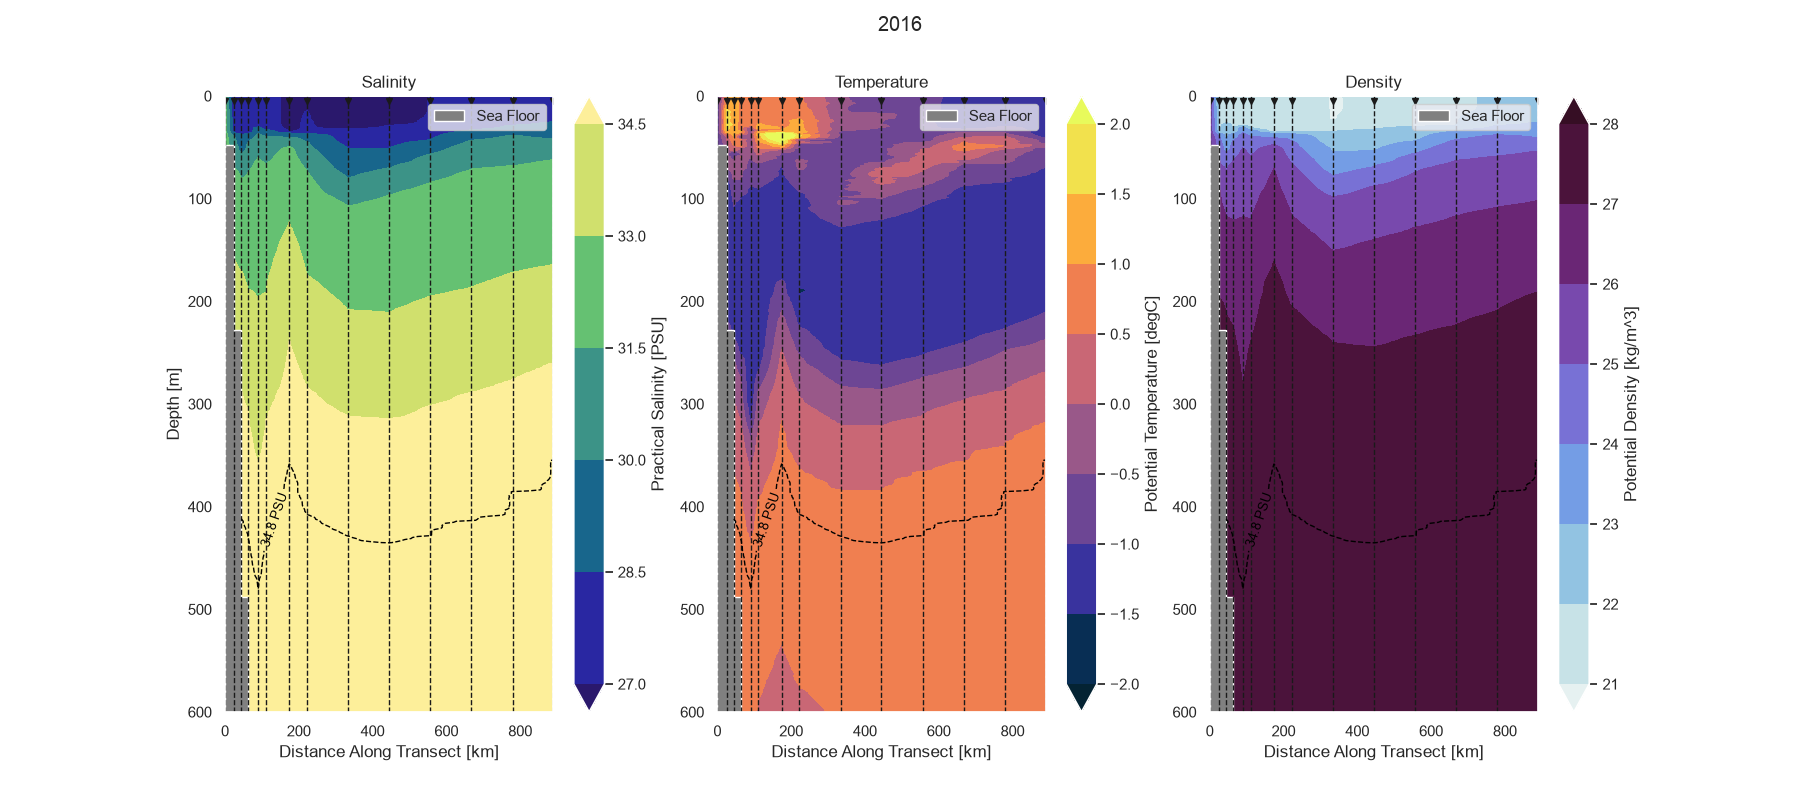

In [24]:
default_year = 2016

sns.set_theme()

ct_fig = plt.figure(figsize=(18,8))

year_slider = widgets.IntSlider(
    value=default_year,
    min=2003,
    max=2025,
    step=1,
    description='Year:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

def plot_ct_transect(change, fig):
    fig.clf()
    axs = fig.subplots(1,3) 

    year = change['new']
    transect = e_ns_cruise_transects[year]

    fig, axs[0] = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'psal',
        fig = fig,
        ax = axs[0],
        cmap = cm.haline,
        title = f'Salinity',
        bounds = {'top': 0, 'bottom': 600, 'left': 0, 'right': None}
        )

    fig, axs[1] = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'ptmp',
        fig = fig,
        ax = axs[1],
        cmap = cm.thermal,
        title = f'Temperature',
        levels=2,
        bounds = {'top': 0, 'bottom': 600, 'left': 0, 'right': None},
        ylabel=False
            )
    fig, axs[2] = plotter.plot_transect(
        transect=transect,
        x = 'distance',
        y = 'depth',
        data = 'pden',
        fig = fig,
        ax = axs[2],
        cmap = cm.dense,
        title = f'Density',
        bounds = {'top': 0, 'bottom': 600, 'left': 0, 'right': None},
        ylabel=False,
        )

    fig.suptitle(str(year))


year_slider.observe(lambda b: plot_ct_transect(b, ct_fig), names='value')

display(year_slider)

#Run callback on startup
plot_ct_transect({'new': default_year}, ct_fig)

plt.show()